**Connect to git repo + install requirements**

In [1]:
import os

#check if the repository folder already exists on the colab disk
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    %cd /content/QML4EO-reproduction
    !git pull
else:
    print("Cloning repo for the first time..")
    %cd /content
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    %cd QML4EO-reproduction

#install required dependencies
!pip install -r requirements.txt -q

Cloning repo for the first time..
/content
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 88 (delta 33), reused 72 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 7.22 MiB | 35.03 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/QML4EO-reproduction
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
from src.baselines.cnn import set_seed, train_baseline
from src.utils.data_loader import get_eurosat_dataloaders
from src.models.hqcnn import HybridQCNN

#setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized: {device}")

Hardware utilized: cuda


**Load Data**

In [3]:
#load data
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

Downloading/Loading EuroSAT dataset into ./data...


100%|██████████| 94.3M/94.3M [00:01<00:00, 68.6MB/s]


Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### **Experiment 3: Entanglement Strategy**

Entanglement is the theoretical core of quantum advantage. It allows qubits to share information in ways classical nodes cannot.

To test its empirical utility; we'll completely ablate the CNOT gates. If the model maintains or improves its accuracy without CNOT gates - it will indicate that the classical optimizer is struggling to navigate the highly correlated, non-convex parameter space created by quantum entanglement.

We test "None" (no entanglement) against "Basic" (a standard ring of CNOT gates).

**Note:** Tested across 3 random seeds for 15 epochs. We hypothesize that unentangled circuits will converge faster initially (smoother loss landscape); but we'll observe if the entangled circuit's higher theoretical capacity overtakes it in later epochs.

In [7]:
import pennylane as qml
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

#define a custom qnode where we can manually control the CNOT gates
def create_experimental_qnode(num_qubits, num_layers, entanglement_type):
    dev = qml.device("default.qubit", wires=num_qubits)

    @qml.qnode(dev, interface="torch")
    def qnode(inputs, weights):
        #encoding
        qml.AngleEmbedding(inputs, wires=range(num_qubits), rotation='Y')

        #parameterized layers
        for layer in range(num_layers):
            # apply trainable rotations to every qubit
            for q in range(num_qubits):
                qml.RY(weights[layer, q], wires=q)

            #apply entanglement strategy
            if entanglement_type == "basic":
                # standard ring of CNOTs
                for q in range(num_qubits):
                    qml.CNOT(wires=[q, (q + 1) % num_qubits])
            elif entanglement_type == "none":
                #literally do nothing. zero quantum correlation.
                pass

        #measurement
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

    return qnode

#custom hybrid model for the ablation
class ExperimentalHQCNN(nn.Module):
    def __init__(self, num_classes=10, num_qubits=4, num_layers=1, entanglement="basic"):
        super(ExperimentalHQCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.bottleneck = nn.Linear(32, num_qubits)

        qnode = create_experimental_qnode(num_qubits, num_layers, entanglement)
        weight_shapes = {"weights": (num_layers, num_qubits)}
        self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc = nn.Linear(num_qubits, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.global_pool(x)
        x = x.view(-1, 32)
        x = self.bottleneck(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc(x)
        return x

# run the rigorous multi-seed loop
entanglement_configs = ["none", "basic"]
SEEDS = [42, 100, 2026]
EPOCHS = 15

entanglement_results = {}
entanglement_histories = {}

print("Starting Rigorous Entanglement Strategy Ablation Study...")

for strategy in entanglement_configs:
    print(f"\n EXPERIMENT: 4 QUBITS, 1 LAYER, '{strategy.upper()}' ENTANGLEMENT ")

    seed_accs = []

    for seed in SEEDS:
        print(f"\n Testing Seed {seed}")
        set_seed(seed)

        model = ExperimentalHQCNN(num_classes=len(classes), num_qubits=4, num_layers=1, entanglement=strategy)
        model = model.to(device)

        history = train_baseline(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            lr=0.001,
            device=device
        )

        seed_accs.append(history['val_acc'])

    #calculate statistics for this strategy
    acc_array = np.array(seed_accs)
    mean_acc = np.mean(acc_array, axis=0)
    std_acc = np.std(acc_array, axis=0)

    entanglement_histories[strategy] = {'mean': mean_acc, 'std': std_acc}
    entanglement_results[strategy] = {
        "final_mean": mean_acc[-1],
        "final_std": std_acc[-1]
    }

print("\nEntanglement Study Complete!")
print("Summary of Results (Mean ± Std Dev):")
for config, metrics in entanglement_results.items():
    print(f"Strategy '{config}': Final Accuracy={metrics['final_mean']:.2f}% ± {metrics['final_std']:.2f}%")

Starting Rigorous Entanglement Strategy Ablation Study...

 EXPERIMENT: 4 QUBITS, 1 LAYER, 'NONE' ENTANGLEMENT 

 Testing Seed 42


Epoch 1/15 [Train]: 100%|██████████| 675/675 [00:27<00:00, 24.30it/s, loss=1.5262]


Epoch 1 Summary -> Train Loss: 1.8992 | Val Accuracy: 40.87%


Epoch 2/15 [Train]: 100%|██████████| 675/675 [00:24<00:00, 27.40it/s, loss=1.5404]


Epoch 2 Summary -> Train Loss: 1.5351 | Val Accuracy: 51.31%


...

Epoch 13 Summary -> Train Loss: 1.0996 | Val Accuracy: 56.74%


Epoch 14/15 [Train]: 100%|██████████| 675/675 [00:27<00:00, 24.70it/s, loss=0.9186]


Epoch 14 Summary -> Train Loss: 1.0810 | Val Accuracy: 59.33%


Epoch 15/15 [Train]: 100%|██████████| 675/675 [00:27<00:00, 24.77it/s, loss=1.0257]


Epoch 15 Summary -> Train Loss: 1.0610 | Val Accuracy: 59.57%

Entanglement Study Complete!
Summary of Results (Mean ± Std Dev):
Strategy 'none': Final Accuracy=76.40% ± 0.82%
Strategy 'basic': Final Accuracy=61.44% ± 2.25%


**Analysis (Entanglement Paradox Confirmed)**

This 15-epoch test confirmed a counter-intuitive phenomenon: removing quantum entanglement drastically improves performance.

* The strategy with zero CNOT gates achieved a 76.40% accuracy with a tight variance of ± 0.82%.
* Removing entanglement turned the quantum layer into a simple and independent linear transformation for each qubit.
* This created a smooth loss landscape (that the classical Adam optimizer can easily navigate).
* The basic strategy using a ring of CNOT gates plateaued at a much lower 61.44% ± 2.25% accuracy.
* Entangling the qubits created a highly correlated and rugged parameter space.
* The entangled circuit has a higher theoretical capacity to represent complex data.
* But, classical optimizers failed to find the optimal weights within this chaotic landscape during a 15-epoch training window.

**Visualization**

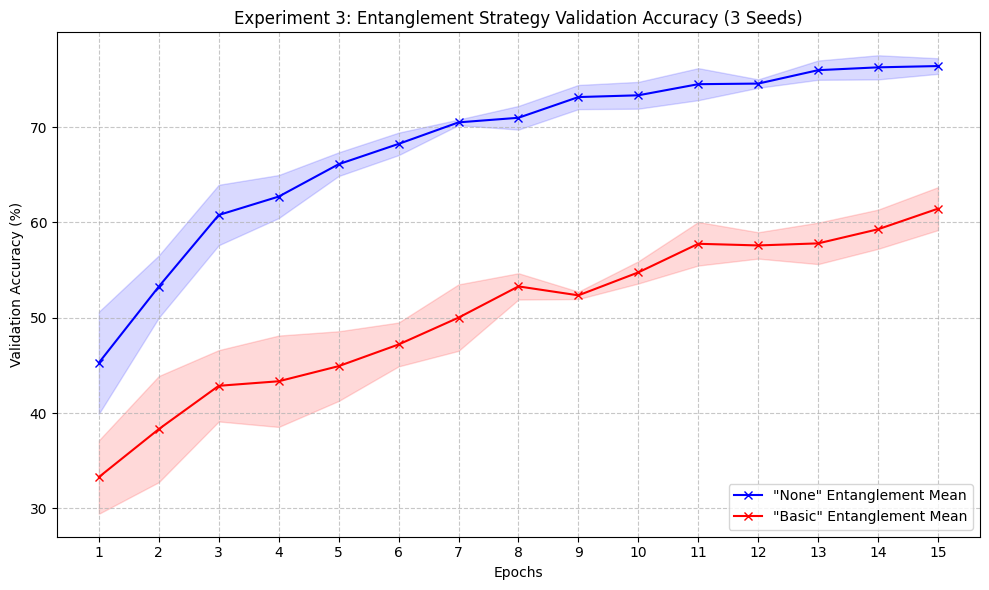

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = {"none": "blue", "basic": "red"}
epochs_range = range(1, EPOCHS + 1)

for strategy, data in entanglement_histories.items():
    mean_acc = data['mean']
    std_acc = data['std']

    plt.plot(epochs_range, mean_acc, label=f'"{strategy.capitalize()}" Entanglement Mean', color=colors[strategy], marker='x')
    plt.fill_between(
        epochs_range,
        mean_acc - std_acc,
        mean_acc + std_acc,
        color=colors[strategy],
        alpha=0.15
    )

plt.title('Experiment 3: Entanglement Strategy Validation Accuracy (3 Seeds)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(epochs_range)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()